In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import timedelta
from timeit import default_timer
import xhistogram.xarray as xhx
import seaborn as sns
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
import matplotlib.colors as colors




In [3]:
dummy = xr.open_mfdataset("/pscratch/sd/a/amahesh/hens/demo_bred_1step/ensemble_out_0000*_2020-06-18-00-00-00.nc",
                     group='global', concat_dim='ensemble', combine='nested')

In [3]:
def load_hens_min_mse(curr_date, curr_date_idx):
    stats_ds = xr.open_dataset(f"/pscratch/sd/a/amahesh/hens_h5/stats_newvar/wind_speed10m_{curr_date:%Y%m%d}_reduced-lead-04-07-10.h5")
    stats_ds = stats_ds.rename({"phony_dim_4" : 'ensemble_size',
                    "phony_dim_2" : 'lat',
                     "phony_dim_3" : 'lon',
                     'phony_dim_1' : 'time'})
    stats_ds['lat'] = dummy['lat']
    stats_ds['lon'] = dummy['lon']
    # Select 10 day lead time
    return stats_ds['wind_speed10m_min_mse_bootstrap_mean'].isel(phony_dim_0=curr_date_idx)
def load_hens_min_mse_interval(curr_date, curr_date_idx):
    stats_ds = xr.open_dataset(f"/pscratch/sd/a/amahesh/hens_h5/stats_newvar/wind_speed10m_{curr_date:%Y%m%d}_reduced-lead-04-07-10.h5")
    stats_ds = stats_ds.rename({"phony_dim_4" : 'ensemble_size',
                "phony_dim_2" : 'lat',
                 "phony_dim_3" : 'lon',
                 'phony_dim_1' : 'time',
                 'phony_dim_5' : 'interval'})
    stats_ds['lat'] = dummy['lat']
    stats_ds['lon'] = dummy['lon']
    return stats_ds['wind_speed10m_min_mse_interval'].isel(phony_dim_0=curr_date_idx)

def load_era5(curr_date):
    valid_date = curr_date + timedelta(days=4)
    print(valid_date)
    true = xr.open_dataset("/pscratch/sd/p/pharring/74var-6hourly/staging/2023.h5", mode='r')
    true = true.rename({'phony_dim_0' : 'time',
                        'phony_dim_2' : 'lat', 
                 'phony_dim_3' : 'lon',
                 'phony_dim_1' : 'channel'})
    true['lat'] = dummy['lat']
    true['lon'] = dummy['lon']
    true['channel'] = ["u10m", "v10m", "u100m", "v100m", "t2m", "sp", "msl", "tcwv", "2d", "u50", "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000", "v50", "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000", "z50", "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000", "t50", "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000", "q50", "q100", "q150", "q200", "q250", "q300", "q400", "q500", "q600", "q700", "q850", "q925", "q1000"]
    true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')

    true = true.sel(time=f"{valid_date:%Y-%m-%d}")
    true_t2m = np.sqrt(true['fields'].sel(channel='u10m')**2 + true['fields'].sel(channel='v10m')**2)
    return true_t2m

def load_mu_sigma(curr_date):
    valid_date = curr_date + timedelta(days=4)
    print(valid_date)
    mu, sigma = [],[]
    for hour in [0,6,12,18]:
        mu.append(xr.open_zarr(f"/pscratch/sd/a/amahesh/hens/thresholds/wind_speed10m_mean_{valid_date.month:02d}_{hour:02d}/").rename({
                        'latitude' : 'lat', 
                        'longitude' : 'lon'}))
        sigma.append(xr.open_zarr(f"/pscratch/sd/a/amahesh/hens/thresholds/wind_speed10m_std_{valid_date.month:02d}_{hour:02d}/").rename({
                        'latitude' : 'lat', 
                        'longitude' : 'lon'}))
    mu = xr.concat(mu, dim='time')
    sigma = xr.concat(sigma, dim='time')
    return mu['wind_speed10m'], sigma['wind_speed10m']

In [4]:
def group_by_leadtime_by_size(hens_min_mse):
    lat_rad = np.deg2rad(hens_min_mse['lat'])
    weights = np.cos(lat_rad)

    # Initialize an empty list to store the results
    results = []

    # Loop over lead_time and ensemble_size
    for lead_time in hens_min_mse['time']:
        current=[]
        for ensemble in hens_min_mse['ensemble_size']:
            # Select the data for the current lead_time and ensemble_size
            data = hens_min_mse.sel(time=lead_time, ensemble_size=ensemble)

            # Calculate the weighted mean
            weighted_mean = data.weighted(weights).mean(('lat', 'lon'))
            # Assign lead_time and ensemble_size as coordinates
            weighted_mean = weighted_mean.expand_dims({'lead_time': [lead_time], 'ensemble_size': [ensemble]})
            current.append(weighted_mean)

            # Append the result to the list
        results.append(current)

    # Concatenate all the results into a single DataArray
    return xr.combine_nested(results, concat_dim=['lead_time', 'ensemble_size'])

In [6]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
all_min_mse_interval, all_era5_zscore = [], []
for idx, curr_date in enumerate(dates):    
    start = default_timer()
    hens_min_mse = load_hens_min_mse_interval(curr_date, idx)
    all_min_mse_interval.append(hens_min_mse.isel(time=[0,1,2,3]))
    print('finished in ', default_timer() - start)
    start = default_timer()
    
    era5 = load_era5(curr_date)
    
    mu, sigma = load_mu_sigma(curr_date)
    
    era5_zscore = (era5 - mu)/sigma
    all_era5_zscore.append(era5_zscore.load().reset_index('time'))
    print('finished in ', default_timer() - start)
   



finished in  0.007800908002536744
2023-06-05 00:00:00
2023-06-05 00:00:00


/tmp/ipykernel_534233/2661043253.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  8.393891924992204
finished in  0.010533659005886875
2023-06-06 00:00:00
2023-06-06 00:00:00


/tmp/ipykernel_534233/2661043253.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  8.567263464996358
finished in  0.010424457999761216
2023-06-07 00:00:00
2023-06-07 00:00:00


...

finished in  9.504220653994707
finished in  0.01756807199853938
2023-09-03 00:00:00
2023-09-03 00:00:00


/tmp/ipykernel_534233/2661043253.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.31657290700241
finished in  0.01713502600614447
2023-09-04 00:00:00
2023-09-04 00:00:00


/tmp/ipykernel_534233/2661043253.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.323692521007615


In [14]:
all_era5_zscore = xr.concat(all_era5_zscore, dim='initial_time')

In [15]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
all_min_mse, global_mean_min_mse = [], []
for idx, curr_date in enumerate(dates):
    start = default_timer()
    hens_min_mse = load_hens_min_mse(curr_date, idx)
    all_min_mse.append(hens_min_mse.isel(time=[0,1,2,3]))
    print('finished in ', default_timer() - start)
   

finished in  0.015608422007062472
finished in  0.013926607003668323
finished in  0.013309315996593796
finished in  0.012152444003731944
finished in  0.011896299998625182
finished in  0.012154158001067117
finished in  0.011911188004887663
finished in  0.012629064003704116
finished in  0.012202722005895339
finished in  0.012002554998616688
finished in  0.012132016010582447
finished in  0.012057542000547983
finished in  0.01208610599860549
finished in  0.01199057200574316
finished in  0.012527076993137598
finished in  0.011949882988119498
finished in  0.011933432004298083
finished in  0.011973568995017558
finished in  0.011938551004277542
finished in  0.01171378900471609
finished in  0.011996203000308014
finished in  0.012153546005720273
finished in  0.011576293007237837
finished in  0.01189217199862469
finished in  0.012024476993246935
finished in  0.011864137995871715
finished in  0.011940384996705689
finished in  0.011660173986456357
finished in  0.011683149001328275
finished in  0.011

In [16]:
all_min_mse = xr.concat(all_min_mse, dim='initial_time')

In [17]:
all_min_mse_interval = xr.concat(all_min_mse_interval, dim='initial_time')

In [18]:
all_min_mse_interval.to_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_min_mse_interval_lead4.zarr",
                            mode='w')

In [19]:
all_era5_zscore.to_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_era5_zscore_lead4.zarr", mode='w')


In [20]:
all_min_mse.to_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_min_mse_lead4.zarr",
                   mode='w')


In [4]:
all_era5_zscore = xr.open_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_era5_zscore_lead4.zarr").load()
all_era5_zscore = all_era5_zscore.rename({'__xarray_dataarray_variable__' : 'Ensemble Minimum RMSE (m/s)'})

In [5]:
all_min_mse = xr.open_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_min_mse_lead4.zarr").load()
all_min_mse_interval = xr.open_zarr("/pscratch/sd/a/amahesh/temp/wind_speed10m_all_min_mse_interval_lead4.zarr").load()


In [6]:
weights = np.cos(np.deg2rad(all_min_mse.lat))
all_min_mse_interval = all_min_mse_interval.assign_coords({'ensemble_size' : [50, 100, 500, 1000, 5000, 7424]})
all_min_mse_interval = all_min_mse_interval.rename({'wind_speed10m_min_mse_interval' : 'Ensemble Minimum RMSE (m/s)'})

In [7]:
all_min_mse = all_min_mse.assign_coords({'ensemble_size' : [50, 100, 500, 1000, 5000, 7424]})
all_min_mse = all_min_mse.rename({'wind_speed10m_min_mse_bootstrap_mean' : 'Ensemble Minimum RMSE (m/s)'})

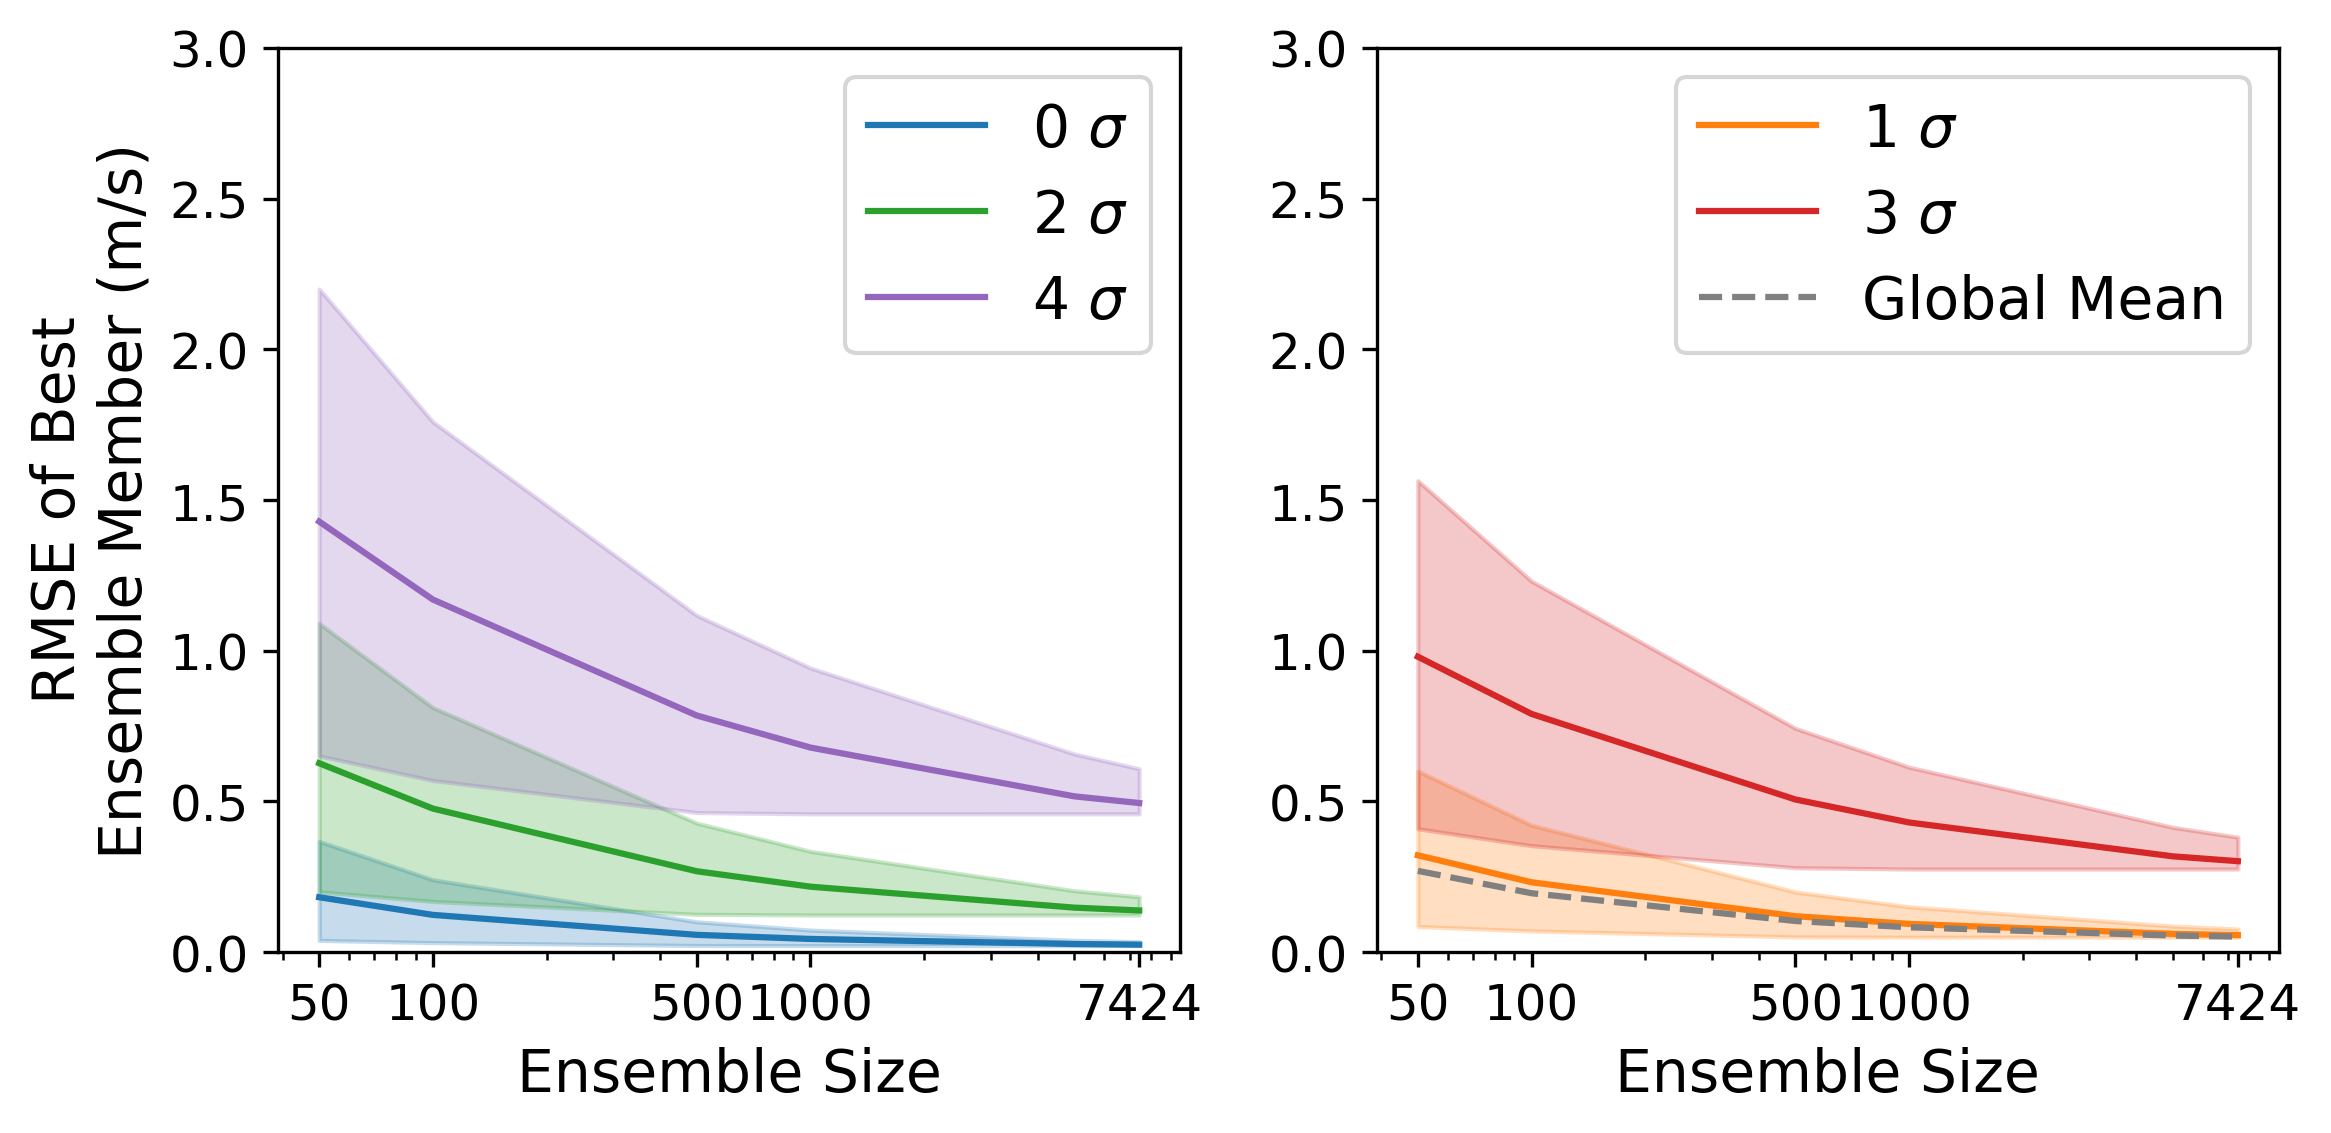

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Define sigma groups for each panel
left_panel_sigmas = [0, 2, 4]
right_panel_sigmas = [1, 3]

# Function to plot for a given panel and sigma values
def plot_sigma(ax, sigmas):
    for sigma in sigmas:
        subset = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse, np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        subset_interval_low = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse_interval.isel(interval=0), np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        subset_interval_high = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse_interval.isel(interval=1), np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))

        ax.plot(subset['ensemble_size'], subset['Ensemble Minimum RMSE (m/s)'].values, label='{} $\sigma$'.format(sigma), color=f"C{sigma}")
        ax.fill_between(subset['ensemble_size'],
                        subset_interval_low['Ensemble Minimum RMSE (m/s)'].values,
                        subset_interval_high['Ensemble Minimum RMSE (m/s)'].values,
                        color=f"C{sigma}", alpha=0.25)
        # subset.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}.nc")
        # subset_interval_low.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}_lowrange.nc")
        # subset_interval_high.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}_highrange.nc")
        

    if 1 in sigmas:
        global_mean = np.sqrt(all_min_mse.weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        ax.plot(global_mean['ensemble_size'], global_mean['Ensemble Minimum RMSE (m/s)'].values, label='Global Mean', color='gray', linestyle='dashed')
    else:
        ax.set_ylabel("RMSE of Best \nEnsemble Member (m/s)")
    ax.set_xscale("log")
    ax.set_xlabel("Ensemble Size")
    ax.set_xticks([50, 100, 500, 1000, 7424])
    ax.set_xticklabels([50, 100, 500, 1000, 7424])
    ax.set_ylim((0, 3))
    ax.legend()

# Plot for left panel
plot_sigma(axs[0], left_panel_sigmas)

# Plot for right panel
plot_sigma(axs[1], right_panel_sigmas)
plt.title("")
plt.tight_layout()
plt.savefig("wind_speed_lead4_rmse_best_member.pdf")
plt.show()
